In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set visual style for Seaborn
sns.set_theme(style="whitegrid")

# Load your dataset (Ensure the filename matches exactly)
dataset_path = "spotify_top_1000_tracks.csv" 
df = pd.read_csv(dataset_path, encoding="utf-8")

print("✅ Dataset loaded successfully!")
df.head()


✅ Dataset loaded successfully!


,track_name,artist,album,release_date,popularity,spotify_url,id,duration_min
0,All The Stars (with SZA),Kendrick Lamar,Black Panther The Album Music From And Inspire...,2018-02-09,95,https://open.spotify.com/track/3GCdLUSnKSMJhs4...,3GCdLUSnKSMJhs4Tj6CV3s,3.869767
1,Starboy,The Weeknd,Starboy,2016-11-25,90,https://open.spotify.com/track/7MXVkk9YMctZqd1...,7MXVkk9YMctZqd1Srtv4MB,3.840883
2,Señorita,Shawn Mendes,Señorita,2019-06-21,80,https://open.spotify.com/track/0TK2YIli7K1leLo...,0TK2YIli7K1leLovkQiNik,3.182667
3,Heat Waves,Glass Animals,Dreamland,2020-08-07,87,https://open.spotify.com/track/3USxtqRwSYz57Ew...,3USxtqRwSYz57Ewm6wWRMp,3.980083
4,Let Me Love You,DJ Snake,Encore,2016-08-05,87,https://open.spotify.com/track/0lYBSQXN6rCTvUZ...,0lYBSQXN6rCTvUZvg9S0lU,3.432433


In [7]:
import pandas as pd
import numpy as np

# Strip column names
df.columns = df.columns.str.strip()

# Clean text columns
text_cols = ['track_name', 'artist', 'album']
for col in text_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()
    else:
        print(f"Warning: {col} not found in dataset.")

# Create 'year' column from release_date
if 'release_date' in df.columns:
    df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
    df['year'] = df['release_date'].dt.year
    df['year'] = pd.to_numeric(df['year'], errors='coerce').fillna(0).astype(int)
    print("✅ Year conversion complete!")
else:
    print("⚠️ release_date column not found in dataset.")

print("✅ Data cleaning complete!")

# Preview cleaned data
print(df[['track_name', 'artist', 'year']].head())


✅ Year conversion complete!
✅ Data cleaning complete!
                 track_name          artist  year
0  All The Stars (with SZA)  Kendrick Lamar  2018
1                   Starboy      The Weeknd  2016
2                  Señorita    Shawn Mendes  2019
3                Heat Waves   Glass Animals  2020
4           Let Me Love You        DJ Snake  2016


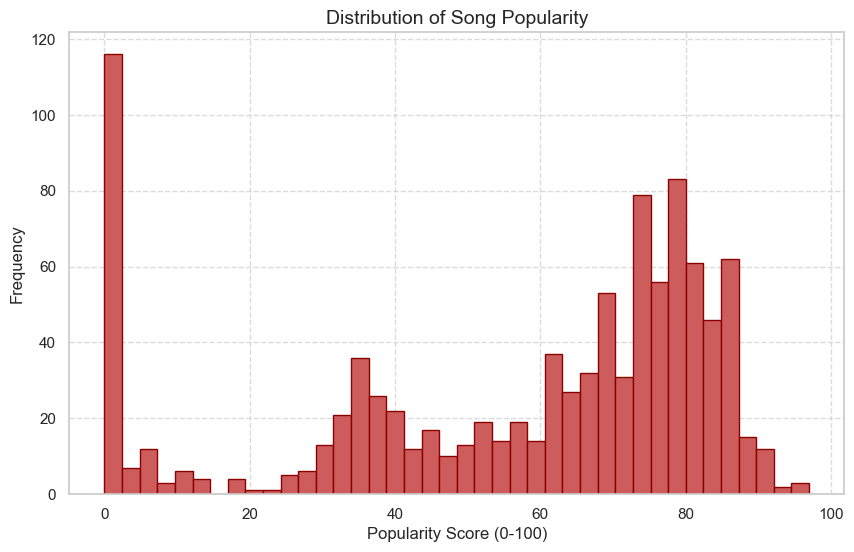

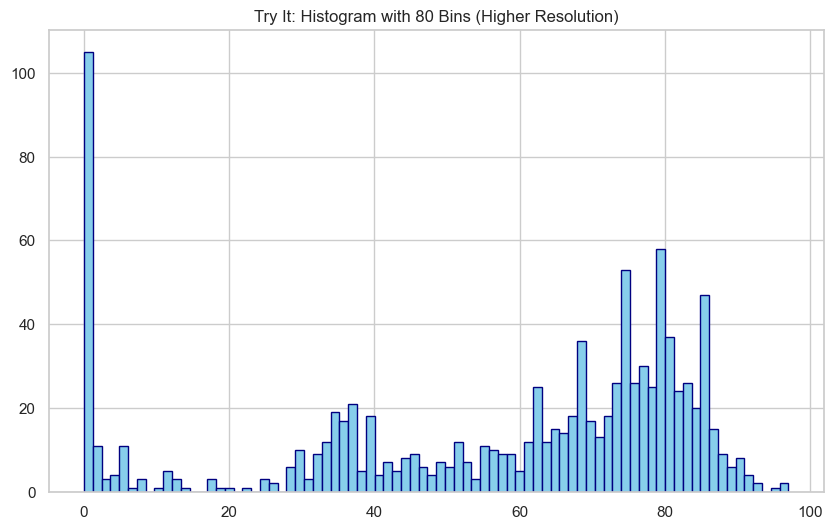

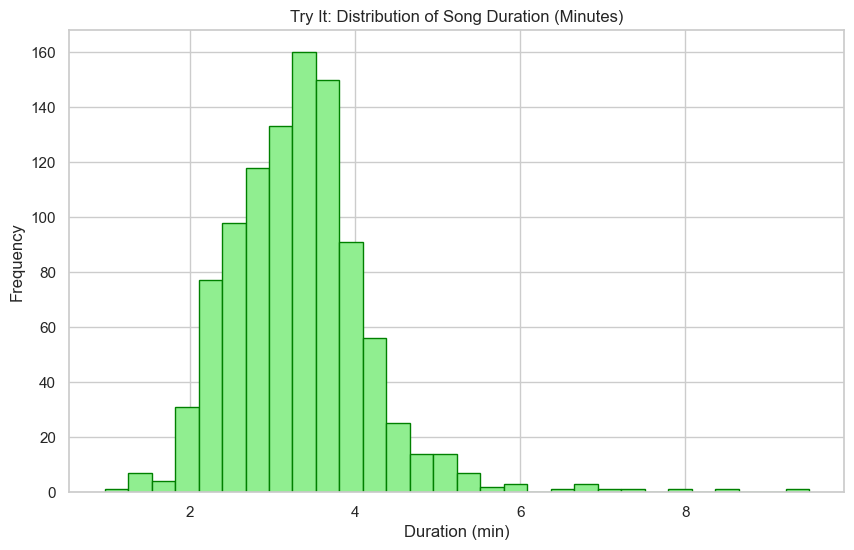

In [8]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))


plt.hist(df['popularity'], bins=40, color='indianred', edgecolor='darkred')


plt.title('Distribution of Song Popularity', fontsize=14)
plt.xlabel('Popularity Score (0-100)')
plt.ylabel('Frequency')


plt.grid(True, linestyle='--', alpha=0.7)


plt.show()

# --- Try It Section ---

plt.figure(figsize=(10, 6))
plt.hist(df['popularity'], bins=80, color='skyblue', edgecolor='navy')
plt.title('Try It: Histogram with 80 Bins (Higher Resolution)')
plt.show()


plt.figure(figsize=(10, 6))
plt.hist(df['duration_min'], bins=30, color='lightgreen', edgecolor='green')
plt.title('Try It: Distribution of Song Duration (Minutes)')
plt.xlabel('Duration (min)')
plt.ylabel('Frequency')
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_23992\781152835.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='year', y='popularity', data=df, palette='viridis')


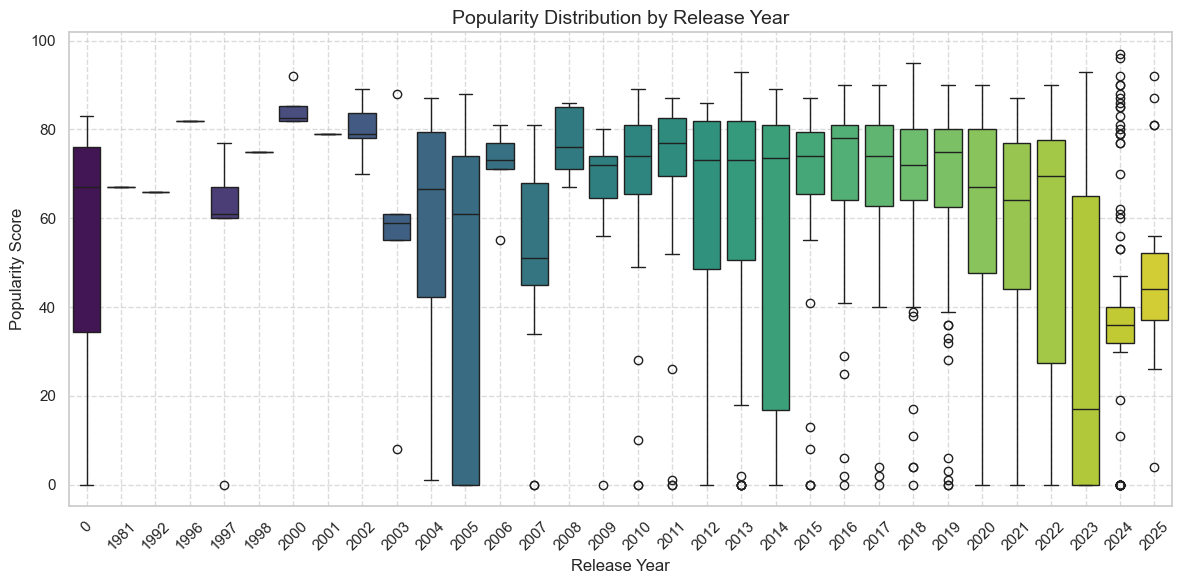

C:\Users\admin\AppData\Local\Temp\ipykernel_23992\781152835.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='year', y='popularity', data=df, palette='magma')


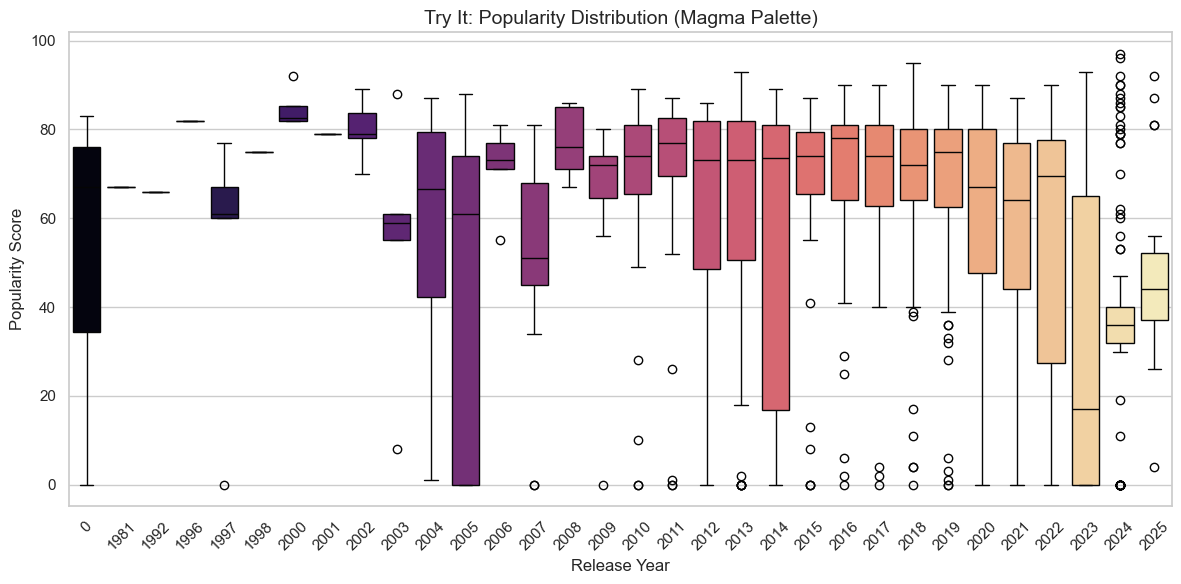

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set Seaborn style for consistency
sns.set_theme(style="whitegrid")

# --- Boxplot with Viridis Palette ---
plt.figure(figsize=(12, 6))
sns.boxplot(x='year', y='popularity', data=df, palette='viridis')

plt.title('Popularity Distribution by Release Year', fontsize=14)
plt.xlabel('Release Year')
plt.ylabel('Popularity Score')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Try It Section: Magma Palette ---
plt.figure(figsize=(12, 6))
sns.boxplot(x='year', y='popularity', data=df, palette='magma')

plt.title('Try It: Popularity Distribution (Magma Palette)', fontsize=14)
plt.xlabel('Release Year')
plt.ylabel('Popularity Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


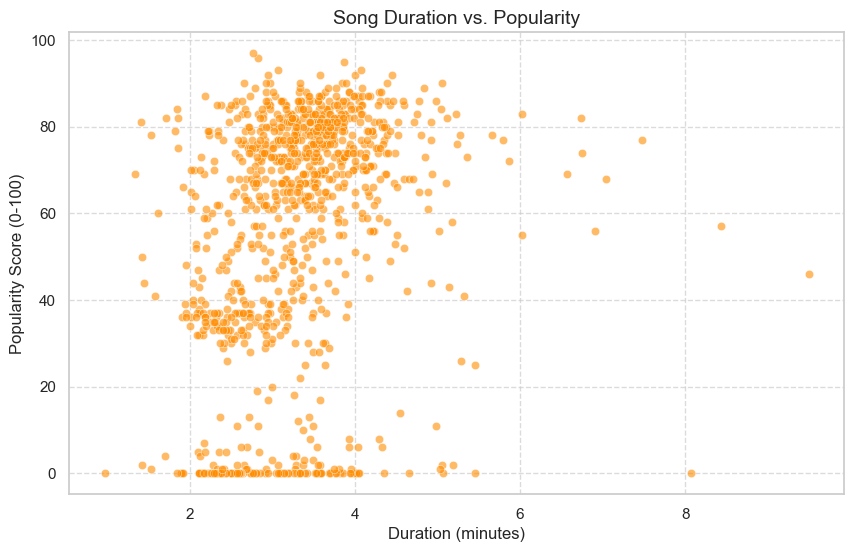

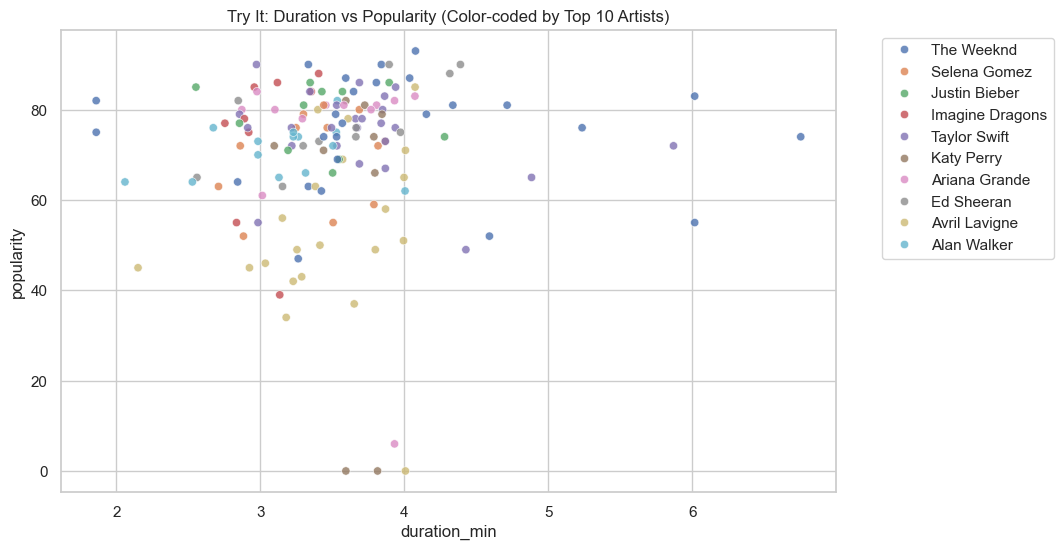

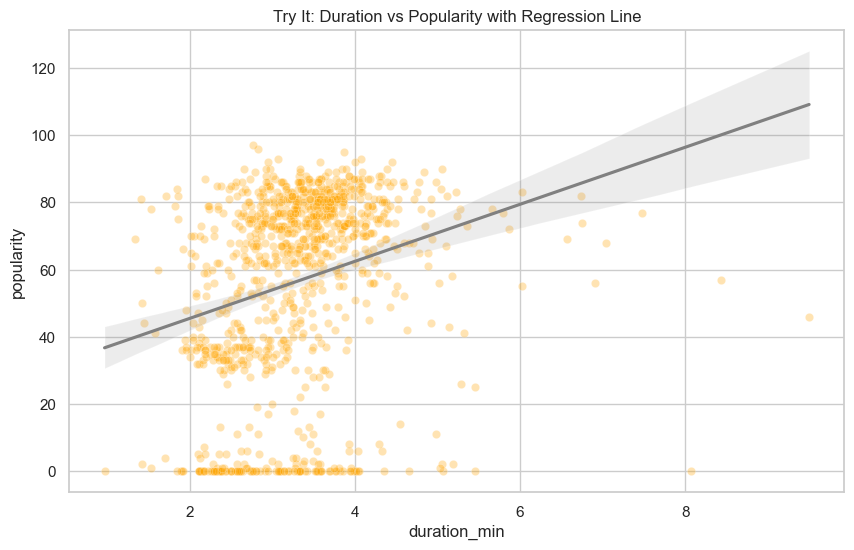

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 6))


sns.scatterplot(x='duration_min', y='popularity', data=df, alpha=0.6, color='darkorange')


plt.title('Song Duration vs. Popularity', fontsize=14)
plt.xlabel('Duration (minutes)')
plt.ylabel('Popularity Score (0-100)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# --- Try It Section ---


top_10_artists = df['artist'].value_counts().nlargest(10).index
filtered_df = df[df['artist'].isin(top_10_artists)]

plt.figure(figsize=(10, 6))
sns.scatterplot(x='duration_min', y='popularity', hue='artist', data=filtered_df, alpha=0.8)
plt.title('Try It: Duration vs Popularity (Color-coded by Top 10 Artists)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.show()


plt.figure(figsize=(10, 6))
sns.scatterplot(x='duration_min', y='popularity', data=df, alpha=0.3, color='orange')

sns.regplot(x='duration_min', y='popularity', data=df, scatter=False, color='grey')
plt.title('Try It: Duration vs Popularity with Regression Line')
plt.show()

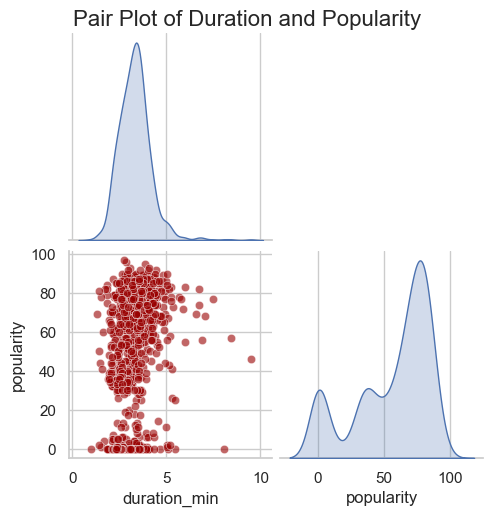


--- Running 'Try It' Variation ---


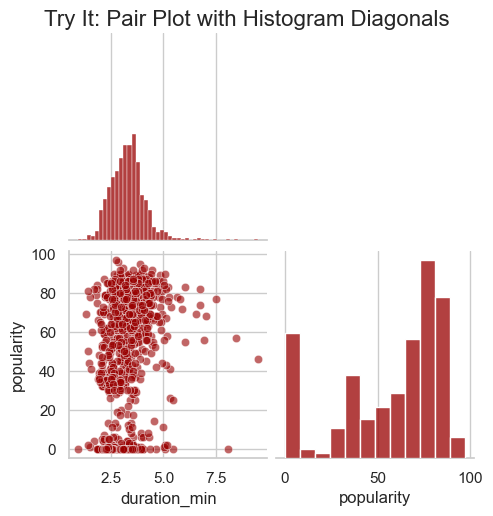

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns


key_features = ['duration_min', 'popularity']


sns.pairplot(
    df[key_features], 
    diag_kind='kde', 
    corner=True,     
    plot_kws={'alpha': 0.6, 'color': '#990000'} 
)


plt.suptitle('Pair Plot of Duration and Popularity', y=1.02, fontsize=16)


plt.show()

# --- Try It Section ---


print("\n--- Running 'Try It' Variation ---")
sns.pairplot(
    df[key_features], 
    diag_kind='hist', 
    corner=True, 
    plot_kws={'alpha': 0.6, 'color': '#990000'},
    diag_kws={'color': '#990000', 'edgecolor': 'white'}
)
plt.suptitle('Try It: Pair Plot with Histogram Diagonals', y=1.02, fontsize=16)
plt.show()

Displaying Main Joint Plot...


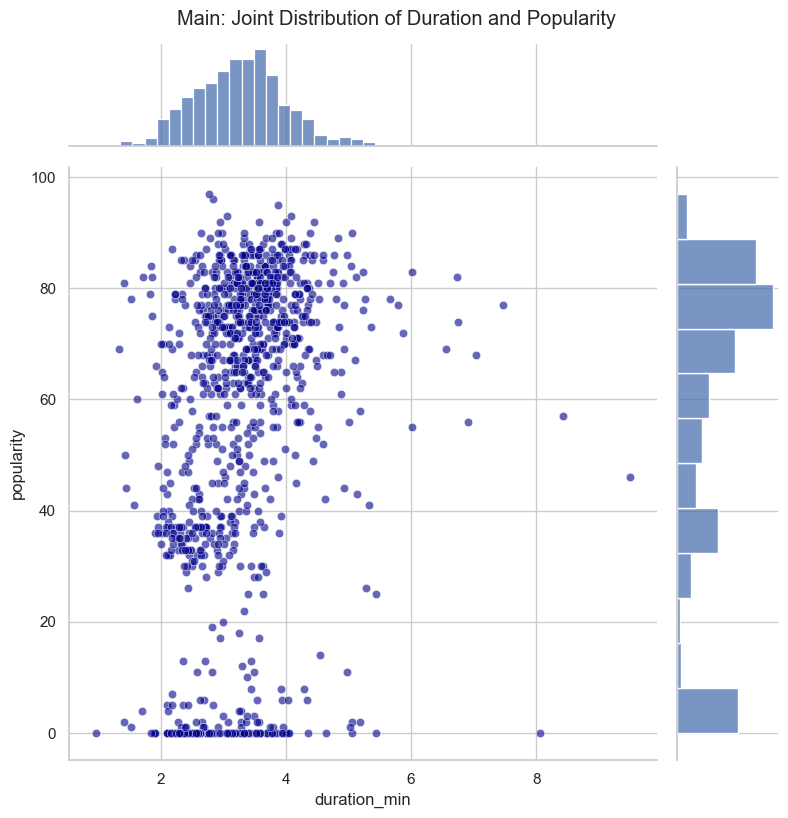


Displaying 'Try It' Variation (Regression + 25 Bins)...


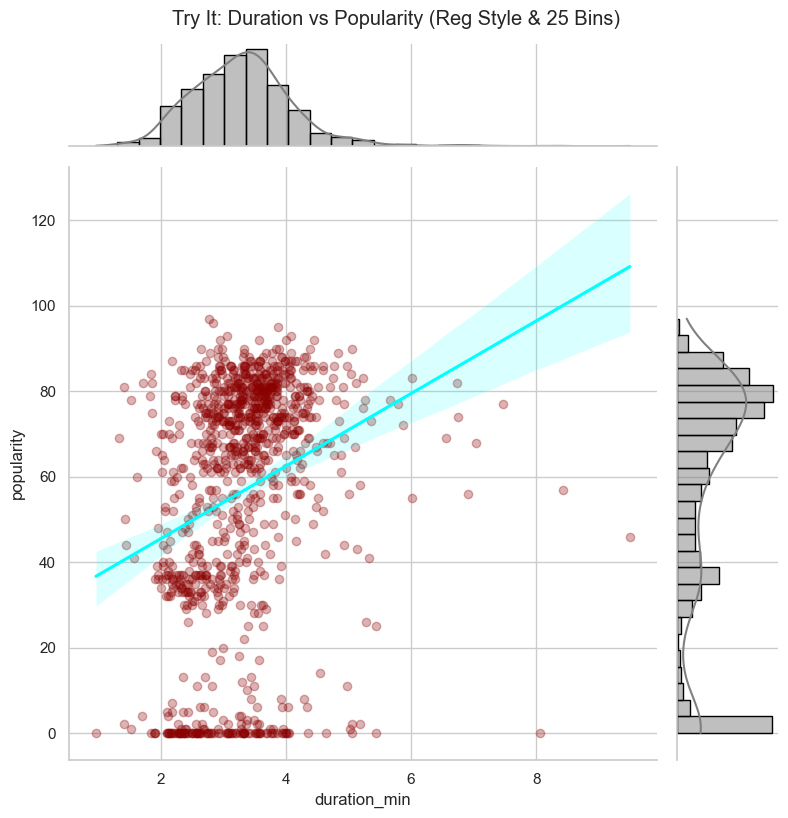

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Use relative path if CSV is in the same folder as notebook
csv_path = "spotify_top_1000_tracks.csv"
df = pd.read_csv(csv_path, encoding="utf-8")

# --- MAIN PART: Standard Scatter Joint Plot ---
print("Displaying Main Joint Plot...")
sns.jointplot(
    x='duration_min',
    y='popularity',
    data=df,
    kind='scatter',
    height=8,
    joint_kws={'alpha': 0.6, 'color': 'darkblue'}
)
plt.suptitle('Main: Joint Distribution of Duration and Popularity', y=1.02)
plt.show()

# --- TRY IT ---
print("\nDisplaying 'Try It' Variation (Regression + 25 Bins)...")
sns.jointplot(
    x='duration_min',
    y='popularity',
    data=df,
    kind='reg',
    height=8,
    marginal_kws=dict(bins=25, color='gray', edgecolor='black'),
    joint_kws={
        'line_kws': {'color': 'cyan'},
        'scatter_kws': {'alpha': 0.3, 'color': 'darkred'}
    }
)
plt.suptitle('Try It: Duration vs Popularity (Reg Style & 25 Bins)', y=1.02)
plt.show()


In [20]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import webbrowser

# --- 1. LOAD DATASET ---
# Since the CSV is in the same folder as your notebook, just use the filename
csv_files = "spotify_top_1000_tracks.csv"
df = pd.read_csv(csv_files, encoding="utf-8")

# --- 2. PREPROCESSING ---
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year
df = df.dropna(subset=['year'])

# Compute average popularity per year
yearly_popularity = df.groupby('year')['popularity'].mean().reset_index().sort_values('year')

# --- 3. ANIMATION FUNCTION ---
def animate(i, line, data):
    subset = data.iloc[:i+1]
    line.set_data(subset['year'], subset['popularity'])
    return line,

# ==========================================================
# --- PART A: MAIN TASK (Standard Speed: 100ms) ---
# ==========================================================
print("Generating Main Task GIF (100ms)...")
fig1, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_xlim(yearly_popularity['year'].min(), yearly_popularity['year'].max())
ax1.set_ylim(0, yearly_popularity['popularity'].max() * 1.1)
line1, = ax1.plot([], [], color='royalblue', linewidth=2.5, label='Average Popularity')
ax1.set_title("Main: Track Popularity Over Time (Standard Speed)", fontsize=14)
ax1.set_xlabel("Year of Release")
ax1.set_ylabel("Average Popularity")
ax1.legend()

ani_main = FuncAnimation(fig1, animate, fargs=(line1, yearly_popularity),
                         frames=len(yearly_popularity), interval=100, repeat=False)

main_gif_path = os.path.abspath("yearly_popularity_main.gif")
ani_main.save(main_gif_path, writer=PillowWriter(fps=10))
print(f"✅ Main GIF saved at: {main_gif_path}")
plt.close(fig1)

# ==========================================================
# --- PART B: TRY IT TASK (Fast Speed: 60ms) ---
# ==========================================================
print("\nGenerating Try It GIF (60ms)...")
fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.set_xlim(yearly_popularity['year'].min(), yearly_popularity['year'].max())
ax2.set_ylim(0, yearly_popularity['popularity'].max() * 1.1)
line2, = ax2.plot([], [], color='crimson', linewidth=2.5, label='Average Popularity')
ax2.set_title("Try It: Track Popularity Over Time (Fast Speed)", fontsize=14)
ax2.set_xlabel("Year of Release")
ax2.set_ylabel("Average Popularity")
ax2.legend()

ani_try = FuncAnimation(fig2, animate, fargs=(line2, yearly_popularity),
                        frames=len(yearly_popularity), interval=60, repeat=False)

try_gif_path = os.path.abspath("yearly_popularity_try_it.gif")
ani_try.save(try_gif_path, writer=PillowWriter(fps=15))
print(f"✅ Try It GIF saved at: {try_gif_path}")
plt.close(fig2)

# --- 4. OPEN GIFS IN BROWSER ---
print("\nOpening both GIFs in your browser...")
webbrowser.open(f"file://{main_gif_path}")
webbrowser.open(f"file://{try_gif_path}")


Generating Main Task GIF (100ms)...
✅ Main GIF saved at: c:\Users\admin\Desktop\Lab7_DataVisualization_Arsoler\yearly_popularity_main.gif

Generating Try It GIF (60ms)...
✅ Try It GIF saved at: c:\Users\admin\Desktop\Lab7_DataVisualization_Arsoler\yearly_popularity_try_it.gif

Opening both GIFs in your browser...


True